In [1]:
import sys
import os
from pathlib import Path

# Robustly find the project root
current_dir = Path(os.getcwd()).resolve()
project_root = None

# Walk up until we find 'model' and 'networks' (current directory structure)
d = current_dir
for _ in range(5):
    if (d / "model").exists() and (d / "networks").exists():
        project_root = d
        break
    if d.parent == d:
        break
    d = d.parent

if project_root:
    if str(project_root) not in sys.path:
        sys.path.append(str(project_root))
    print(f"Project root found at: {project_root}")
else:
    print("Warning: Project root not found automatically. Using absolute fallback.")
    sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..', '')))


Project root found at: /Users/ignacio/Documents/VS Code/GitHub Repositories/e_network_inequality/e_network_inequality


# Basic Testing (Vectorized)

In this notebook we test that the vectorized files work well and produce similar results to the original model.

## Setup

In [2]:
from utils.imports import *
from model.vectorized_model import VectorizedModel
import matplotlib.pyplot as plt


/Users/ignacio/Documents/VS Code/GitHub Repositories/e_network_inequality/e_network_inequality/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Save and load pud_final as JSON
import json
from networkx.readwrite import json_graph
from pathlib import Path

JSON_PATH = Path("../../networks/citation_data/pud_final.json")

# Save to JSON
def save_network_json(G, path):
    data = json_graph.node_link_data(G)
    with open(path, "w") as f:
        json.dump(data, f)
    print(f"Saved network to {path}")

# Load from JSON
def load_network_json(path):
    with open(path, "r") as f:
        data = json.load(f)
    # Fix for networkx expecting 'edges' instead of 'links' or vice-versa
    if "links" in data and "edges" not in data:
        data["edges"] = data["links"]
    G = json_graph.node_link_graph(data)
    print(f"Loaded network from {path}")
    return G

# Example usage:
# save_network_json(pud_final, JSON_PATH)
my_network = load_network_json(JSON_PATH)

Loaded network from ../../networks/citation_data/pud_final.json


/Users/ignacio/Documents/VS Code/GitHub Repositories/e_network_inequality/e_network_inequality/.venv/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


In [4]:
# n_agents = 1000
# my_network = nx.gnp_random_graph(n_agents, p=0.1, directed=True) #nx.complete_graph(n_agents, create_using=nx.DiGraph())

## Try with Bayes Agent (Vectorized)

In [5]:
seed=420
my_model = VectorizedModel(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,
                 seed=seed,seeded=False, agent_type='bayes')
my_model.run_simulation(number_of_steps=50000,show_bar=True)
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)
print('conclusion core', my_model.conclusion_core)

df_bayes = pd.DataFrame(my_model.credences_history).T
df_bayes.head(3)

100%|██████████| 50000/50000 [00:15<00:00, 3132.60it/s]


steps:  50000
conclusion:  0.47126436781609193
conclusion core 0.6666666666666666


,0,1,2,3,4,5,6,7,8,9,...,77,78,79,80,81,82,83,84,85,86
0,0.062735,0.245783,0.139661,0.845022,0.166696,0.192117,0.363169,0.000079,0.448057,0.1044,...,0.540582,0.702147,0.465843,0.515773,0.232526,0.653461,0.714191,0.722518,0.188513,0.677535
1,0.062735,0.245783,0.136802,0.845022,0.165587,0.192117,0.361321,0.000078,0.448057,0.1044,...,0.536606,0.702147,0.465843,0.515773,0.232526,0.653461,0.714191,0.719299,0.188513,0.675785
2,0.062735,0.245783,0.138703,0.846066,0.165587,0.192117,0.361321,0.000078,0.448057,0.1044,...,0.536606,0.705483,0.465843,0.517770,0.232526,0.655270,0.712556,0.720911,0.188513,0.677535


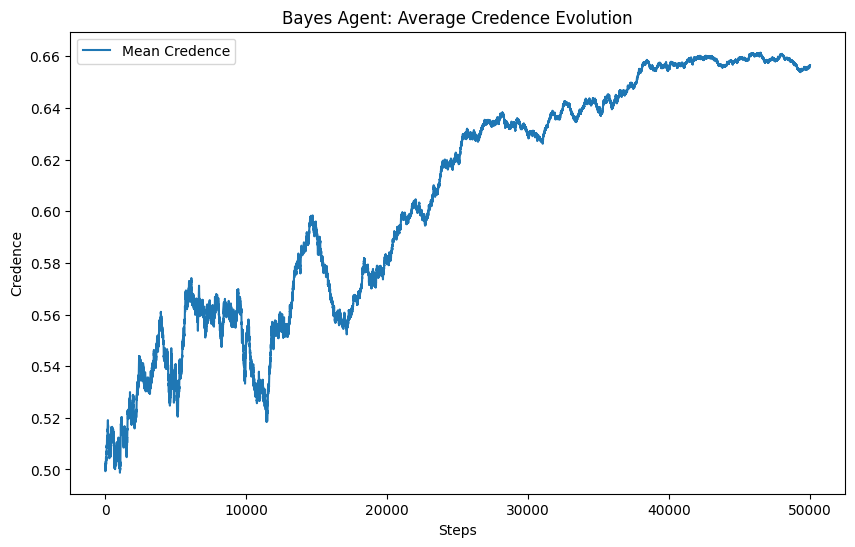

In [6]:
# Plot mean credence for Bayes
# Credences are 1D arrays (scalar per agent)
mean_credence = df_bayes.mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(mean_credence, label='Mean Credence')
plt.title('Bayes Agent: Average Credence Evolution')
plt.xlabel('Steps')
plt.ylabel('Credence')
plt.legend()
plt.show()

## Try with Beta Agent (Vectorized)

In [7]:
seed=420
my_model = VectorizedModel(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,
                 seed=seed,seeded=False, agent_type='beta')

my_model.run_simulation(number_of_steps=10000,show_bar=True)
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)

# agent_histories in VectorizedModel is a list of lists of numpy arrays
df = pd.DataFrame(my_model.credences_history).T # Transpose because history[agent] is list of steps
df.head(3)

 76%|███████▋  | 7638/10000 [00:03<00:01, 2253.05it/s]


steps:  7639
conclusion:  0.632183908045977


,0,1,2,3,4,5,6,7,8,9,...,77,78,79,80,81,82,83,84,85,86
0,"[0.203916685070411, 0.6426599477312006]","[0.0005391706806371128, 0.9272940979825066]","[0.6689282590355905, 0.5100134704910126]","[0.19253130479273883, 0.5169318032751938]","[0.9855572072362517, 0.6346335503483508]","[0.5969823504728837, 0.12434699664581901]","[0.24089204547566542, 0.4905683551311313]","[0.8112056110294291, 0.00286105169046143]","[0.5975569834694225, 0.09789766921914182]","[0.22809652874947198, 0.17994459464207427]",...,"[0.9458407284353227, 0.4535874264585351]","[0.20943390969649345, 0.28066705184185325]","[0.04749022967859082, 4.1129597506542825e-39]","[0.30169946903223455, 0.754573712287109]","[0.9617223269527432, 0.8216381056157837]","[0.8158024023147918, 0.7537748054278105]","[0.3445073757431742, 0.22968071758713948]","[0.9409950924416401, 8.48630758005843e-06]","[0.8979530697742578, 0.669907925929315]","[0.6874986637529487, 0.4038819868039055]"
1,"[0.5193852567120424, 0.32436073644789204]","[0.579118384711664, 0.7834690796622897]","[0.5089758462559733, 0.48774951519855336]","[0.2799130461322081, 0.2879115434810533]","[0.368892231931834, 0.5809440006879926]","[0.8154775773441175, 0.6202618776385814]","[0.4983563673625892, 0.4819592040263614]","[0.5515263530651814, 0.650489486285625]","[0.5194134133072997, 0.2736707547580519]","[0.33199386160815714, 0.03784328380145096]",...,"[0.44653004105939437, 0.5987102025876451]","[0.23288903137165343, 0.5755046921792718]","[0.33974150714560236, 0.11234992706960924]","[0.4807577258480977, 0.5213015175307832]","[0.38198995853244744, 0.03853764441285871]","[0.45037358117532056, 0.45916889495614893]","[0.4622340653161387, 0.4626271026703855]","[0.2804706621556866, 0.49096756511255285]","[0.5207625474826443, 0.1367190127310598]","[0.3820361919794095, 0.5069158640541791]"
2,"[0.509601492154932, 0.5977034984833951]","[0.4922967496647715, 0.5036014734141714]","[0.5107196834096387, 0.4843154946518533]","[0.4277251291900908, 0.5162891480291213]","[0.5955387885527574, 0.5370551351317656]","[0.5266060346653312, 0.45000669839894497]","[0.4680826955544389, 0.5255825693462981]","[0.5079969865778302, 0.47700214658677764]","[0.39665169020547336, 0.3454182066327753]","[0.42718788938786006, 0.41494321624295494]",...,"[0.6132247463670741, 0.4465928644972883]","[0.48847105479444725, 0.4223927151440183]","[0.2592784421133341, 0.4545815224824162]","[0.5477993934750949, 0.47352678172257356]","[0.625759591467536, 0.17414060586162203]","[0.2432934368583814, 0.3755673215688814]","[0.49675536020189487, 0.4829661888389013]","[0.29716176577725095, 0.5606048857325088]","[0.41128942037197475, 0.6476723187046479]","[0.38328079026210016, 0.5391700440916188]"


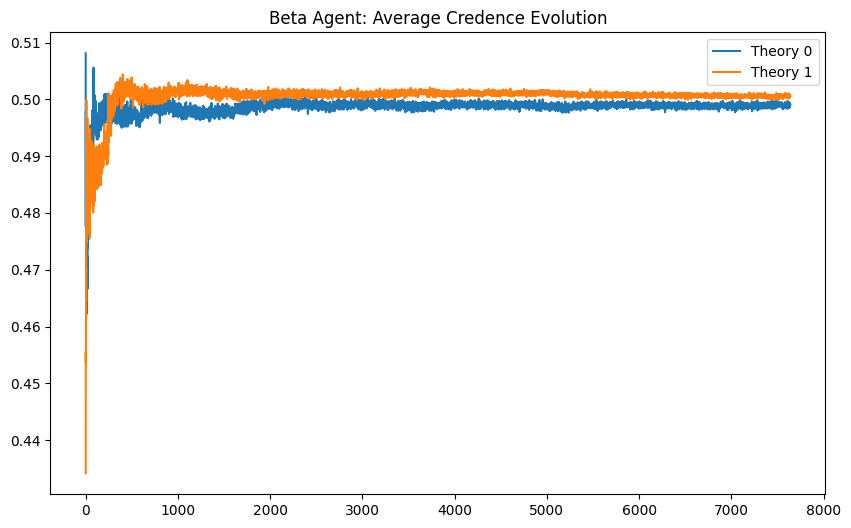

In [8]:
# Extract the first coordinate (x) for each pair and calculate column-wise mean
# In vectorized model, credences are stored as arrays [c0, c1].
x_means = df.map(lambda pair: pair[0]).mean(axis=1)
y_means = df.map(lambda pair: pair[1]).mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(x_means, label='Theory 0')
plt.plot(y_means, label='Theory 1')
plt.title('Beta Agent: Average Credence Evolution')
plt.legend()
plt.show()

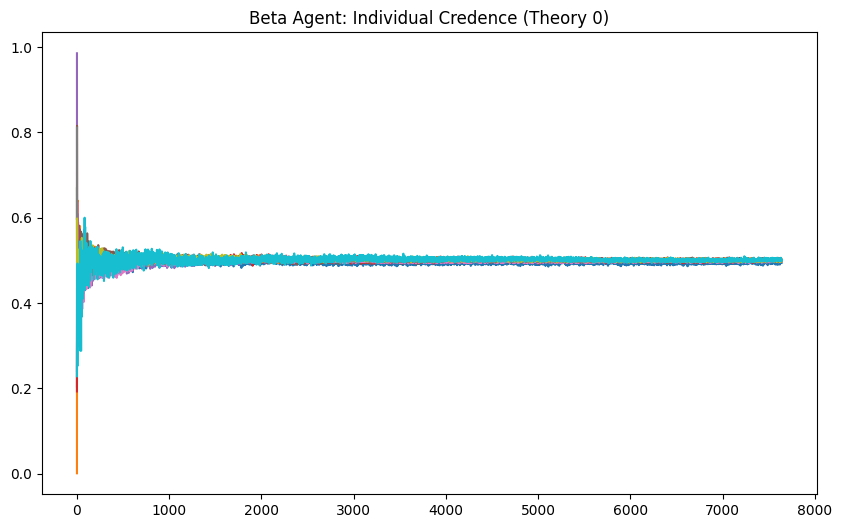

In [9]:
# Extract the first coordinate (x) for each pair
x_values = df.map(lambda pair: pair[0])

# Plot the first coordinate for each row (agent)
plt.figure(figsize=(10, 6))
# Plot a subset of agents to avoid clutter if N is large
for agent_idx in range(min(10, x_values.shape[1])):
    plt.plot(x_values[agent_idx], label=f'Agent {agent_idx}')
plt.title('Beta Agent: Individual Credence (Theory 0)')
plt.show()